# dataset description
## Presidential election winner by department (1st round, 2026)
**source**: registraduria nacional del estado civil

**dataset**: [resultados elecciones presidenciales 2026](https://resultados.registraduria.gov.co/territorios/0/00/)

# code
## imports

In [19]:
import json

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from highlight_text import fig_text

pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [20]:
path = "./data/elecciones_2026.csv"
df = pd.read_csv(path, encoding="utf-8")

with open("./data/colombia_departments.geojson", encoding="utf-8") as f:
    geo = json.load(f)

## Clean data

In [21]:
def get_winners(df: pd.DataFrame) -> dict:
    cand = df[(df["Tipo"].eq("Candidato")) & (df["Codigo"].notna())].copy()
    top = cand.loc[cand.groupby("Codigo")["Votos"].idxmax()]
    top["code"] = top["Codigo"].astype(int).astype(str).str.zfill(2)
    return dict(zip(top["code"], top["Concepto"]))

winners = get_winners(df)

## Plot

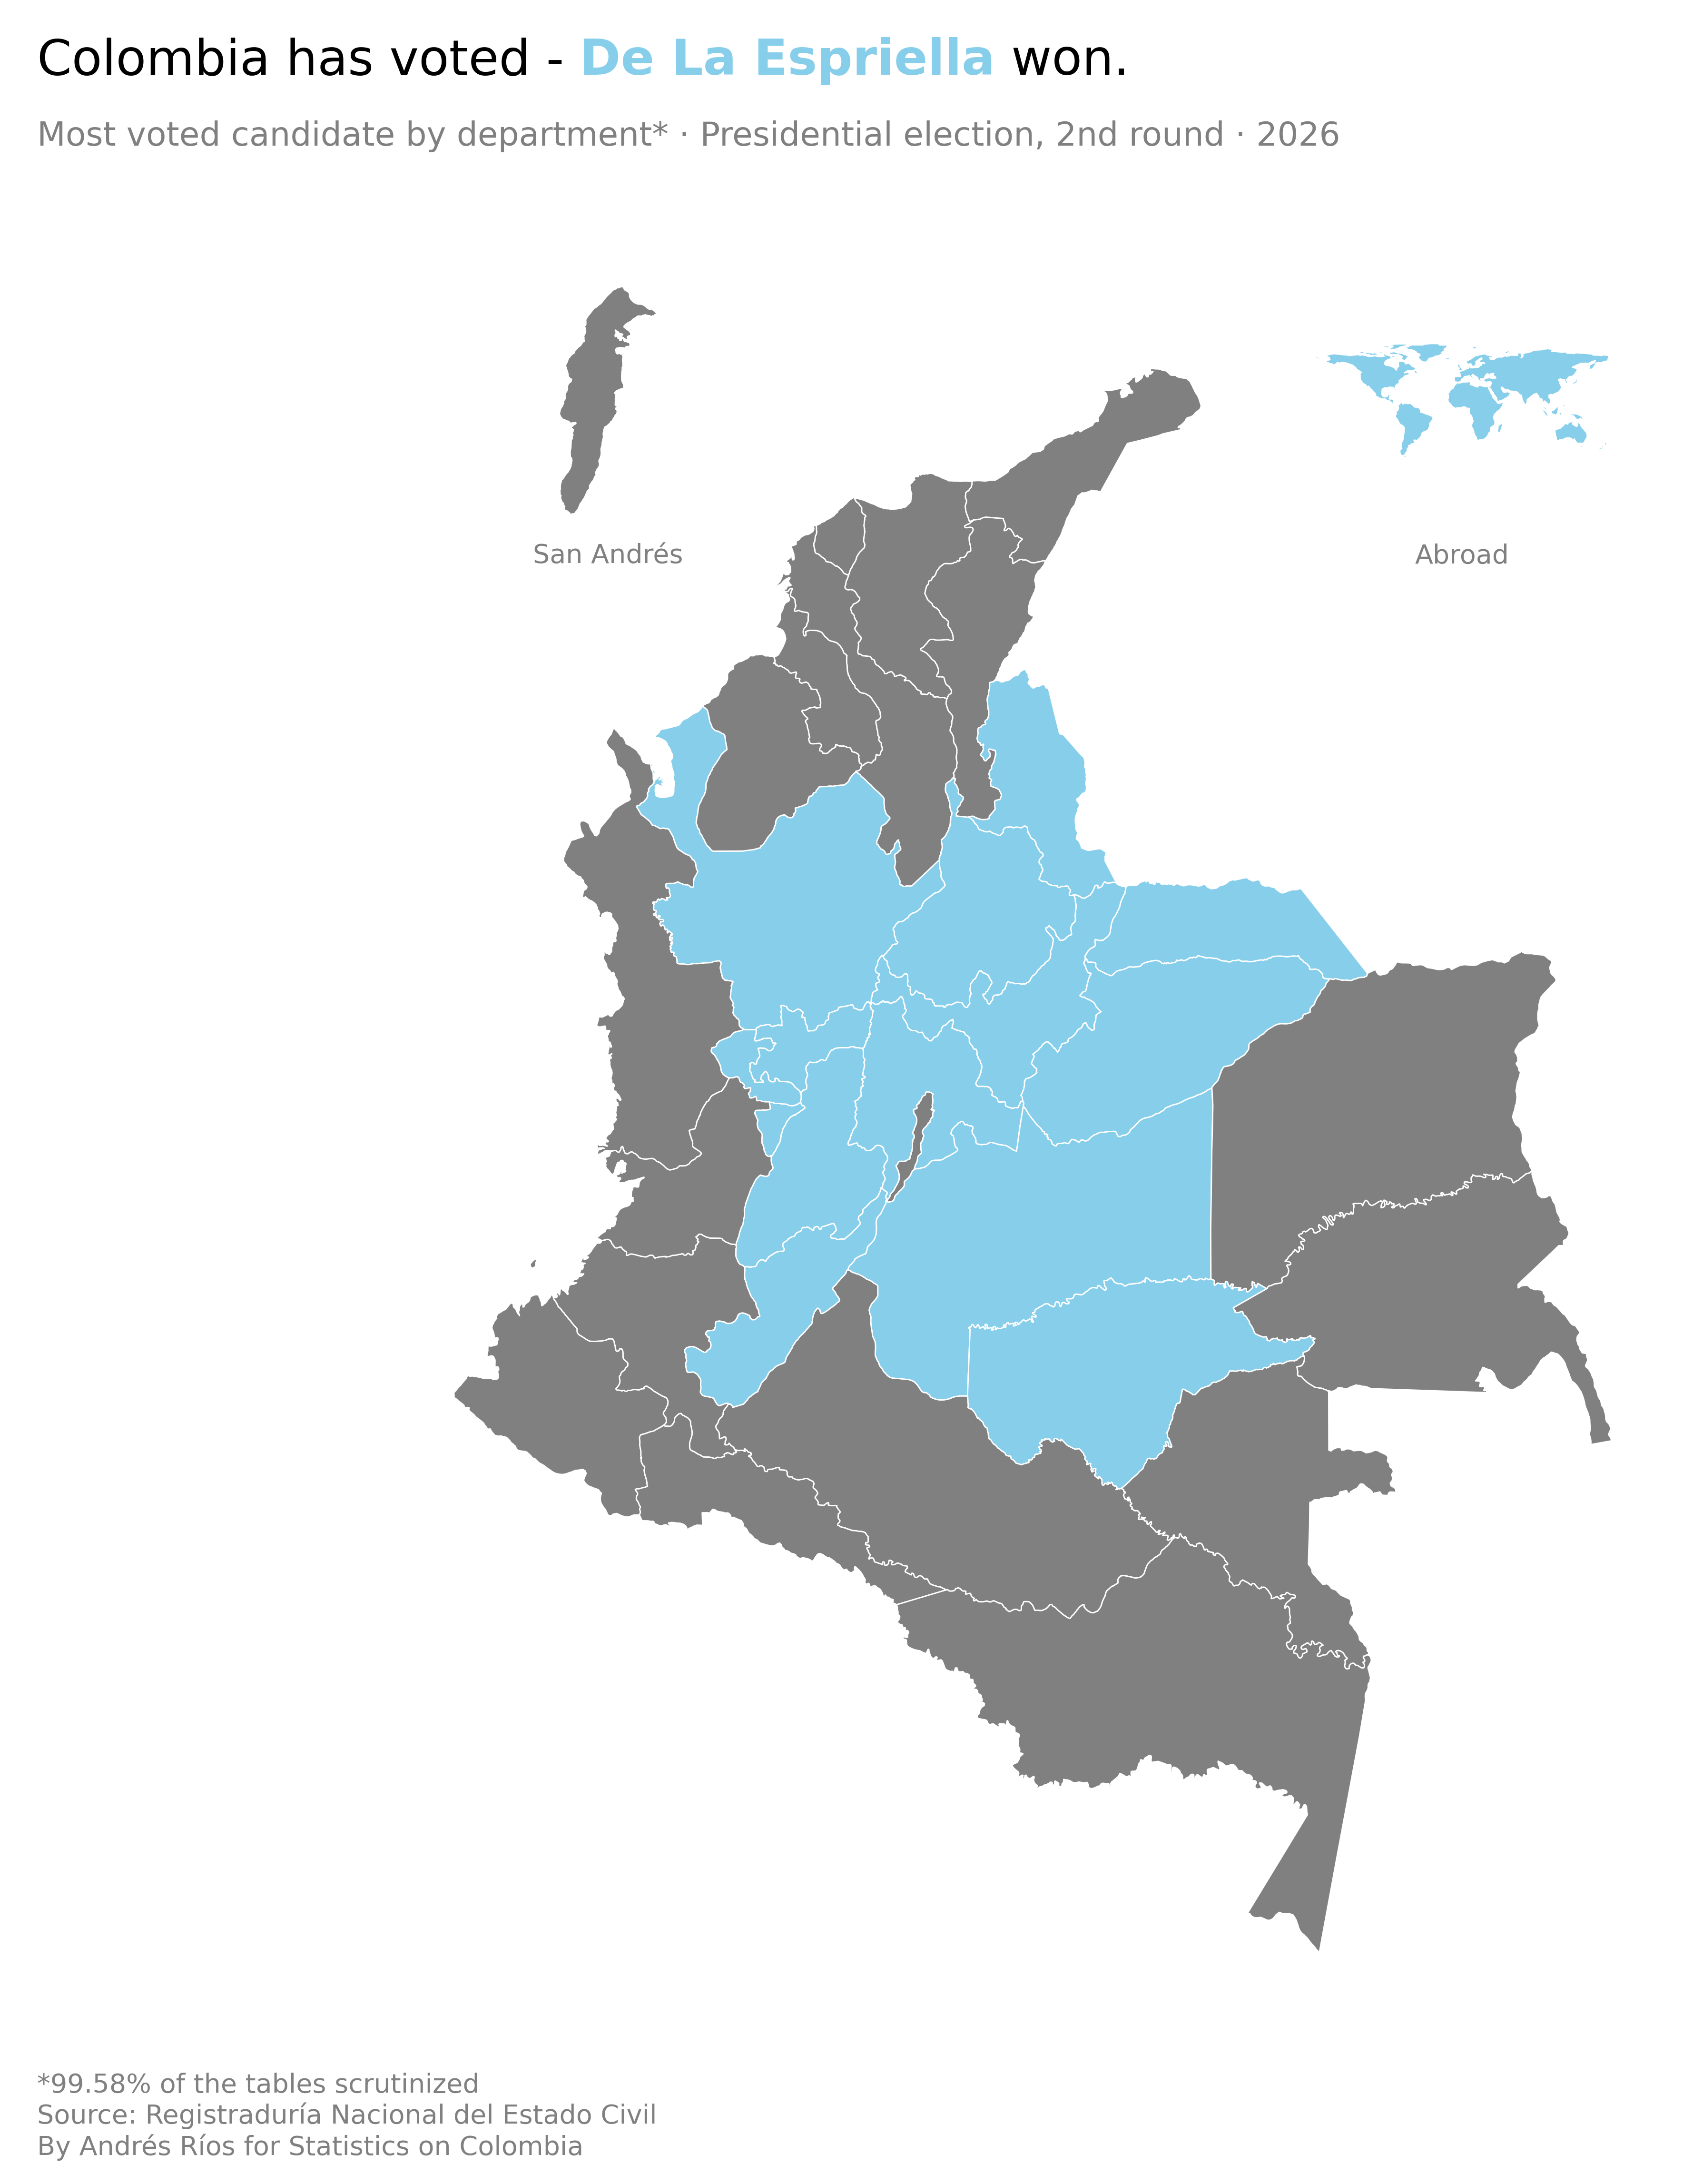

In [22]:
win_color = "skyblue"
lose_color = "gray"
missing_color = "#e8e8e8"

national = (df[(df["Ambito"].eq("NACIONAL")) & (df["Tipo"].eq("Candidato"))]
            .nlargest(2, "Votos")["Concepto"].tolist())
winner_name, runner_name = national
winner_label = " ".join(winner_name.split()[1:]).title()
candidate_color = {winner_name: win_color, runner_name: lose_color}

def exterior_rings(geometry: dict) -> list:
    if geometry["type"] == "Polygon":
        return [geometry["coordinates"][0]]
    return [poly[0] for poly in geometry["coordinates"]]

def fit_box(rings: list, box: dict) -> list:
    """Uniform scale + center rings into a target lon/lat box (preserve aspect)."""
    xs = [x for r in rings for x, _ in r]
    ys = [y for r in rings for _, y in r]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    bx0, bx1 = box["lon"]
    by0, by1 = box["lat"]
    scale = min((bx1 - bx0) / (x1 - x0), (by1 - by0) / (y1 - y0))
    ox = bx0 + ((bx1 - bx0) - (x1 - x0) * scale) / 2
    oy = by0 + ((by1 - by0) - (y1 - y0) * scale) / 2
    return [[(ox + (x - x0) * scale, oy + (y - y0) * scale) for x, y in r]
            for r in rings]

sanandres_box = {"lon": (-79.0, -75.9), "lat": (10.9, 13.3)}

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)

patches, colors = [], []
for feat in geo["features"]:
    winner = winners.get(feat["properties"]["DPTO"])
    color = candidate_color.get(winner, missing_color)
    rings = exterior_rings(feat["geometry"])
    if feat["properties"]["DPTO"] == "88":
        def bbox_area(r):
            xs = [x for x, _ in r]; ys = [y for _, y in r]
            return (max(xs) - min(xs)) * (max(ys) - min(ys))
        main = max(rings, key=bbox_area)
        rings = fit_box([main], sanandres_box)
    for ring in rings:
        patches.append(Polygon(ring, closed=True))
        colors.append(color)

ax.add_collection(PatchCollection(
    patches, facecolor=colors, edgecolor="white", linewidth=0.4))
ax.autoscale_view()
ax.set_aspect("equal")
ax.axis("off")

ax.text(-68.45, 10.6, "Abroad", fontsize=8, color="gray",
        ha="center", va="top")

ax.text(-77.45, 10.6, "San Andrés", fontsize=8, color="gray",
        ha="center", va="top")

fig_text(
    x=0.125, y=0.95,
    s=f"Colombia has voted - <{winner_label}> won.",
    highlight_textprops=[{"color": win_color, "weight": "bold"}],
    fontsize=15,
)

fig_text(
    x=0.125, y=0.915,
    s="Most voted candidate by department* · Presidential election, 2nd round · 2026",
    fontsize=10, color="gray",
)

fig.text(
    0.125, 0.06,
    "*99.58% of the tables scrutinized\nSource: Registraduría Nacional del Estado Civil\n"
    "By Andrés Ríos for Statistics on Colombia",
    fontsize=8, color="gray")

plt.show()